<a href="https://colab.research.google.com/github/Snjkmr162/The_Pricing_Analytics_Toolkit/blob/main/notebooks/week2_markdown/Week2_Markdown_Optimization.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import glob

In [2]:
from google.colab import files
uploaded = files.upload()
os.makedirs('/root/.kaggle', exist_ok=True)

Saving kaggle.json to kaggle.json


In [3]:
kaggle_files = glob.glob('/content/kaggle*.json')
print(f"Found: {kaggle_files}")
!cp "{kaggle_files[0]}" /root/.kaggle/kaggle.json
!chmod 600 /root/.kaggle/kaggle.json

!pip install -q kaggle
!kaggle competitions download -c walmart-recruiting-store-sales-forecasting
!unzip -o walmart-recruiting-store-sales-forecasting.zip -d walmart_data
!unzip -o walmart_data/train.csv.zip -d walmart_data
!unzip -o walmart_data/test.csv.zip -d walmart_data
!unzip -o walmart_data/features.csv.zip -d walmart_data

train = pd.read_csv("walmart_data/train.csv", parse_dates=["Date"])
features = pd.read_csv("walmart_data/features.csv", parse_dates=["Date"])
stores = pd.read_csv("walmart_data/stores.csv")

df = train.merge(features, on=["Store", "Date", "IsHoliday"], how="left")
df = df.merge(stores, on="Store", how="left")

print(f"Data loaded: {df.shape}")

Found: ['/content/kaggle.json']
100% 2.70M/2.70M [00:00<00:00, 75.8MB/s]

Archive:  walmart-recruiting-store-sales-forecasting.zip
  inflating: walmart_data/features.csv.zip  
  inflating: walmart_data/sampleSubmission.csv.zip  
  inflating: walmart_data/stores.csv  
  inflating: walmart_data/test.csv.zip  
  inflating: walmart_data/train.csv.zip  
Archive:  walmart_data/train.csv.zip
  inflating: walmart_data/train.csv  
Archive:  walmart_data/test.csv.zip
  inflating: walmart_data/test.csv   
Archive:  walmart_data/features.csv.zip
  inflating: walmart_data/features.csv  
Data loaded: (421570, 16)


In [4]:
markdown_cols = ["MarkDown1", "MarkDown2", "MarkDown3", "MarkDown4", "MarkDown5"]

print("Markdown data availability:")
for col in markdown_cols:
    non_null = features[col].notna().sum()
    total = len(features)
    pct = non_null / total * 100
    print(f"  {col}: {non_null:,} non-null rows out of {total:,} ({pct:.1f}%)")

print(f"\nEarliest markdown date: {features[features['MarkDown1'].notna()]['Date'].min()}")
print(f"Latest markdown date:   {features[features['MarkDown1'].notna()]['Date'].max()}")

print("\nMarkdown value ranges:")
print(features[markdown_cols].describe().round(2))

Markdown data availability:
  MarkDown1: 4,032 non-null rows out of 8,190 (49.2%)
  MarkDown2: 2,921 non-null rows out of 8,190 (35.7%)
  MarkDown3: 3,613 non-null rows out of 8,190 (44.1%)
  MarkDown4: 3,464 non-null rows out of 8,190 (42.3%)
  MarkDown5: 4,050 non-null rows out of 8,190 (49.5%)

Earliest markdown date: 2011-11-11 00:00:00
Latest markdown date:   2013-07-26 00:00:00

Markdown value ranges:
       MarkDown1  MarkDown2  MarkDown3  MarkDown4  MarkDown5
count    4032.00    2921.00    3613.00    3464.00    4050.00
mean     7032.37    3384.18    1760.10    3292.94    4132.22
std      9262.75    8793.58   11276.46    6792.33   13086.69
min     -2781.45    -265.76    -179.26       0.22    -185.17
25%      1577.53      68.88       6.60     304.69    1440.83
50%      4743.58     364.57      36.26    1176.42    2727.14
75%      8923.31    2153.35     163.15    3310.01    4832.56
max    103184.98  104519.54  149483.31   67474.85  771448.10


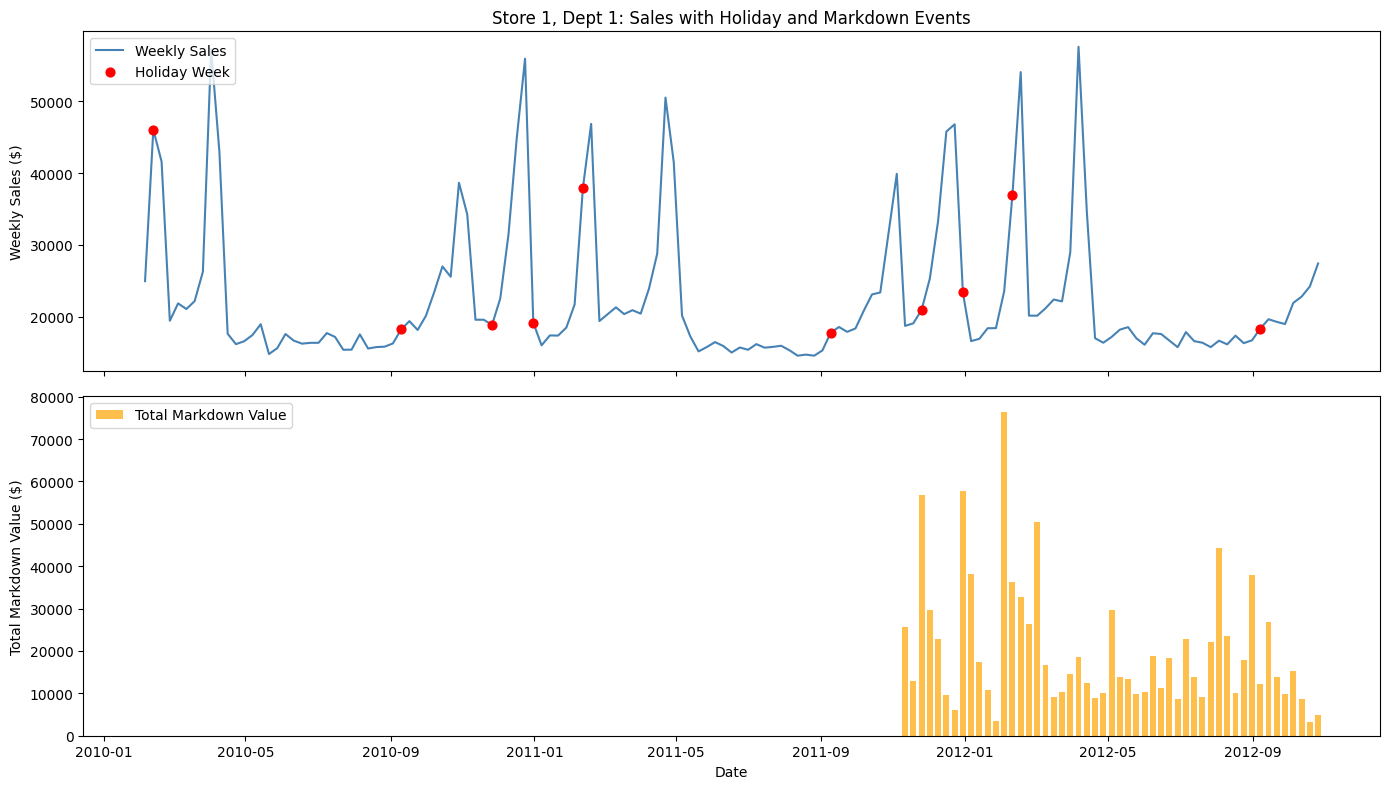

In [5]:
store_data = df[(df["Store"] == 1) & (df["Dept"] == 1)].copy()
store_data = store_data.sort_values("Date").reset_index(drop=True)

# Create a combined markdown indicator
store_data["Total_Markdown"] = store_data[markdown_cols].sum(axis=1)
store_data["Has_Markdown"] = store_data["Total_Markdown"] > 0

fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

# Top: Weekly sales with holiday flags
axes[0].plot(store_data["Date"], store_data["Weekly_Sales"],
             color="steelblue", linewidth=1.5, label="Weekly Sales")
axes[0].scatter(store_data[store_data["IsHoliday"]]["Date"],
                store_data[store_data["IsHoliday"]]["Weekly_Sales"],
                color="red", zorder=5, label="Holiday Week", s=40)
axes[0].set_ylabel("Weekly Sales ($)")
axes[0].set_title("Store 1, Dept 1: Sales with Holiday and Markdown Events")
axes[0].legend(loc="upper left")

# Bottom: Total markdown value over time
axes[1].bar(store_data["Date"], store_data["Total_Markdown"],
            color="orange", alpha=0.7, width=5, label="Total Markdown Value")
axes[1].set_ylabel("Total Markdown Value ($)")
axes[1].set_xlabel("Date")
axes[1].legend(loc="upper left")

plt.tight_layout()
plt.savefig("week2_day6_markdown_overview.png", dpi=150)
plt.show()

In [6]:
holiday_sales = store_data[store_data["IsHoliday"]]["Weekly_Sales"]
non_holiday_sales = store_data[~store_data["IsHoliday"]]["Weekly_Sales"]
markdown_sales = store_data[store_data["Has_Markdown"]]["Weekly_Sales"]
no_markdown_sales = store_data[~store_data["Has_Markdown"]]["Weekly_Sales"]

print("Sales comparison (Store 1, Dept 1):")
print(f"  Average holiday week sales:     ${holiday_sales.mean():,.0f}")
print(f"  Average non-holiday week sales: ${non_holiday_sales.mean():,.0f}")
print(f"  Holiday lift:                   {(holiday_sales.mean() / non_holiday_sales.mean() - 1):.1%}")
print(f"\n  Average markdown week sales:    ${markdown_sales.mean():,.0f}")
print(f"  Average no-markdown week sales: ${no_markdown_sales.mean():,.0f}")
print(f"  Markdown lift:                  {(markdown_sales.mean() / no_markdown_sales.mean() - 1):.1%}")

Sales comparison (Store 1, Dept 1):
  Average holiday week sales:     $25,739
  Average non-holiday week sales: $22,271
  Holiday lift:                   15.6%

  Average markdown week sales:    $22,641
  Average no-markdown week sales: $22,443
  Markdown lift:                  0.9%


In [7]:
markdown_cols = ["MarkDown1", "MarkDown2", "MarkDown3", "MarkDown4", "MarkDown5"]

test_combos = [(1,1), (1,2), (1,3), (2,1), (2,2), (3,1), (3,2), (4,1), (5,1), (5,2)]

lift_results = []

for store_id, dept_id in test_combos:
    subset = df[(df["Store"] == store_id) & (df["Dept"] == dept_id)].copy()
    if len(subset) < 10:
        continue
    subset = subset.sort_values("Date").reset_index(drop=True)

    subset["Total_Markdown"] = subset[markdown_cols].clip(lower=0).sum(axis=1)
    subset["Has_Markdown"] = subset["Total_Markdown"] > 0

    markdown_sales = subset[subset["Has_Markdown"]]["Weekly_Sales"]
    no_markdown_sales = subset[~subset["Has_Markdown"]]["Weekly_Sales"]

    if len(markdown_sales) == 0 or len(no_markdown_sales) == 0:
        continue

    lift = (markdown_sales.mean() / no_markdown_sales.mean() - 1) * 100

    lift_results.append({
        "Store-Dept": f"S{store_id}-D{dept_id}",
        "Markdown_Weeks": len(markdown_sales),
        "Avg_Sales_Markdown": markdown_sales.mean(),
        "Avg_Sales_No_Markdown": no_markdown_sales.mean(),
        "Lift_Pct": lift
    })

lift_df = pd.DataFrame(lift_results).sort_values("Lift_Pct", ascending=False)
print(lift_df.to_string(index=False))

Store-Dept  Markdown_Weeks  Avg_Sales_Markdown  Avg_Sales_No_Markdown  Lift_Pct
     S3-D1              51         8647.482353            6597.513152 31.071847
     S3-D2              51        18788.741569           15762.479348 19.199151
     S5-D1              51        10547.572549            9346.031413 12.856164
     S4-D1              51        38287.847255           36254.904565  5.607359
     S1-D3              51        13584.400588           12909.934022  5.224400
     S5-D2              51        12721.012941           12094.518043  5.179991
     S1-D2              51        46890.488824           45665.043478  2.683552
     S2-D1              51        30960.040980           30677.056087  0.922464
     S2-D2              51        66290.337647           65703.703261  0.892848
     S1-D1              51        22640.571961           22442.782717  0.881304


In [8]:
best_combo = lift_df.iloc[0]["Store-Dept"]
best_store, best_dept = int(best_combo.split("-")[0][1:]), int(best_combo.split("-")[1][1:])

print(f"Building decay curve for: {best_combo} (highest lift: {lift_df.iloc[0]['Lift_Pct']:.1f}%)")

decay_data = df[(df["Store"] == best_store) & (df["Dept"] == best_dept)].copy()
decay_data = decay_data.sort_values("Date").reset_index(drop=True)
decay_data["Total_Markdown"] = decay_data[markdown_cols].clip(lower=0).sum(axis=1)

# Find markdown event weeks (local peaks in markdown spend)
decay_data["Is_Peak_Markdown"] = (
    (decay_data["Total_Markdown"] > decay_data["Total_Markdown"].quantile(0.85)) &
    (decay_data["Total_Markdown"] > 0)
)

peak_weeks = decay_data[decay_data["Is_Peak_Markdown"]].index.tolist()
print(f"Found {len(peak_weeks)} peak markdown weeks")

Building decay curve for: S3-D1 (highest lift: 31.1%)
Found 22 peak markdown weeks


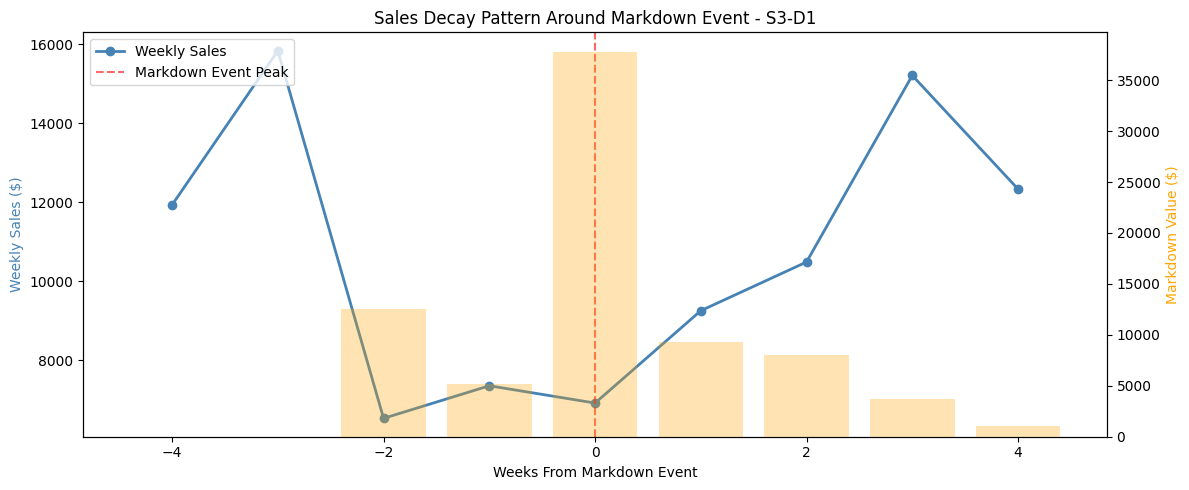

In [9]:
biggest_peak_idx = decay_data["Total_Markdown"].idxmax()
window_start = max(0, biggest_peak_idx - 4)
window_end = min(len(decay_data), biggest_peak_idx + 5)

window = decay_data.iloc[window_start:window_end].copy()
window["Weeks_From_Event"] = range(-(biggest_peak_idx - window_start), window_end - biggest_peak_idx)

fig, ax1 = plt.subplots(figsize=(12, 5))

ax1.plot(window["Weeks_From_Event"], window["Weekly_Sales"],
         marker="o", color="steelblue", linewidth=2, label="Weekly Sales")
ax1.axvline(x=0, color="red", linestyle="--", alpha=0.6, label="Markdown Event Peak")
ax1.set_xlabel("Weeks From Markdown Event")
ax1.set_ylabel("Weekly Sales ($)", color="steelblue")
ax1.legend(loc="upper left")

ax2 = ax1.twinx()
ax2.bar(window["Weeks_From_Event"], window["Total_Markdown"],
        alpha=0.3, color="orange", label="Markdown Value")
ax2.set_ylabel("Markdown Value ($)", color="orange")

plt.title(f"Sales Decay Pattern Around Markdown Event - {best_combo}")
plt.tight_layout()
plt.savefig("week2_day7_decay_curve.png", dpi=150)
plt.show()

In [10]:
# ---------------------------------------------------------
# Investigate: what's actually happening around the
# markdown peak for S3-D1
# ---------------------------------------------------------
print(window[["Date", "IsHoliday", "Weekly_Sales", "Total_Markdown", "Weeks_From_Event"]].to_string(index=False))

      Date  IsHoliday  Weekly_Sales  Total_Markdown  Weeks_From_Event
2011-10-28      False      11932.26            0.00                -4
2011-11-04      False      15836.73            0.00                -3
2011-11-11      False       6525.18        12570.12                -2
2011-11-18      False       7350.22         5217.89                -1
2011-11-25       True       6912.38        37800.11                 0
2011-12-02      False       9251.40         9342.90                 1
2011-12-09      False      10485.08         8040.79                 2
2011-12-16      False      15210.07         3722.77                 3
2011-12-23      False      12332.52         1088.40                 4
